Architecture Two:
* Uses only two convolutional layer
* Tested using different loss functions (weighted & unweighted, hinge)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import os
from PIL import Image

from myDataset import *

# imports loss, accuracy and confusion matrix plots
from MetricMethods import *

# imports train, test methods
from ArchitectureMethods import *



seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.cuda.empty_cache()

# Sets current directory as ws
print(os.getcwd())
os.chdir('..')
print(os.getcwd())
# Checks if device is available (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/user/HS401/ob00564/Documents/COM3001/Custom All
/user/HS401/ob00564/Documents/COM3001
cuda


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831376].


Train set length: 3241
Test set length: 404
Validation set length: 408
torch.Size([3, 224, 224]) 0
0


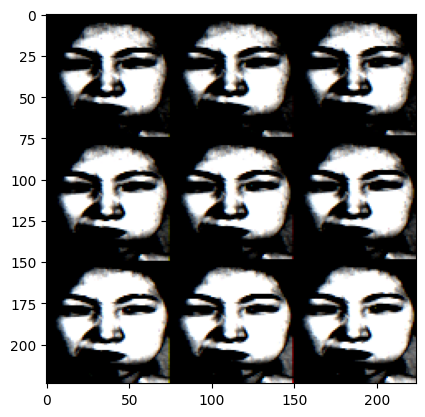

In [3]:
# Dataset Creation
train_dataset = myDataset(directory = "Custom All/DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "Custom All/DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "Custom All/DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

# DataLoader Creation
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers=8)

# View shape of data
train_iter = iter(train_dataset)
img, label = next(train_iter)
print(img.shape, label)

np_img = img.numpy()
print(label)
plt.imshow(np_img.reshape((224,224,3)))



In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

class ArchitectureTwo(nn.Module):
    
    def __init__(self):
        super(ArchitectureTwo, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)  
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  
        
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)  

        self.batch_norm1 = nn.BatchNorm2d(32)
        self.batch_norm2 = nn.BatchNorm2d(64)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(56 * 56 * 64, 7)

        self.dropout1 = nn.Dropout(p=0.3)
        self.dropout2 = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout2(x)

        
        x = self.flatten(x)
        x = self.fc(x)
        return x


100%|██████████| 203/203 [00:06<00:00, 32.16it/s]


Adam
Epoch 1/25, Training Loss: 1.7076, Validation Loss: 1.3993
Epoch 1/25, Training Acc: 38.34838533114395, Validation Accuracy: 51.442307692307686
SGD
Epoch 1/25, Training Loss: 10.5869, Validation Loss: 1.6346
Epoch 1/25, Training Acc: 32.73125342090859, Validation Accuracy: 43.99038461538461


100%|██████████| 203/203 [00:06<00:00, 32.65it/s]


Adam
Epoch 2/25, Training Loss: 1.3223, Validation Loss: 1.2359
Epoch 2/25, Training Acc: 52.28858784893268, Validation Accuracy: 55.04807692307693
SGD
Epoch 2/25, Training Loss: 1.3997, Validation Loss: 1.2920
Epoch 2/25, Training Acc: 50.673918992884516, Validation Accuracy: 55.769230769230774


100%|██████████| 203/203 [00:06<00:00, 32.79it/s]


...

Adam
Epoch 23/25, Training Loss: 0.5021, Validation Loss: 0.7145
Epoch 23/25, Training Acc: 82.66625615763546, Validation Accuracy: 76.92307692307693
SGD
Epoch 23/25, Training Loss: 0.7080, Validation Loss: 0.8306
Epoch 23/25, Training Acc: 74.45949644225506, Validation Accuracy: 72.35576923076923


100%|██████████| 203/203 [00:06<00:00, 32.14it/s]


Adam
Epoch 24/25, Training Loss: 0.4704, Validation Loss: 0.7191
Epoch 24/25, Training Acc: 84.18171866447727, Validation Accuracy: 77.88461538461539
SGD
Epoch 24/25, Training Loss: 0.6982, Validation Loss: 0.8200
Epoch 24/25, Training Acc: 75.37629994526546, Validation Accuracy: 70.4326923076923


100%|██████████| 203/203 [00:06<00:00, 32.08it/s]


Adam
Epoch 25/25, Training Loss: 0.4852, Validation Loss: 0.7216
Epoch 25/25, Training Acc: 82.08128078817734, Validation Accuracy: 75.96153846153845
SGD
Epoch 25/25, Training Loss: 0.6857, Validation Loss: 0.7721
Epoch 25/25, Training Acc: 76.02969348659003, Validation Accuracy: 72.35576923076923
Models saved successfully!
Test Loss: 0.8370, Test Accuracy: 71.32%
Test Loss: 0.8587, Test Accuracy: 70.34%


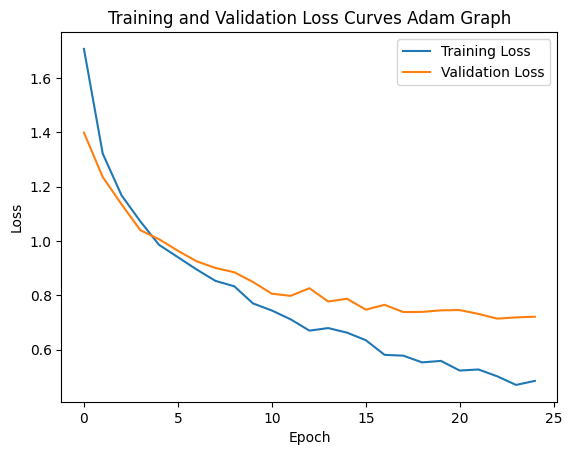

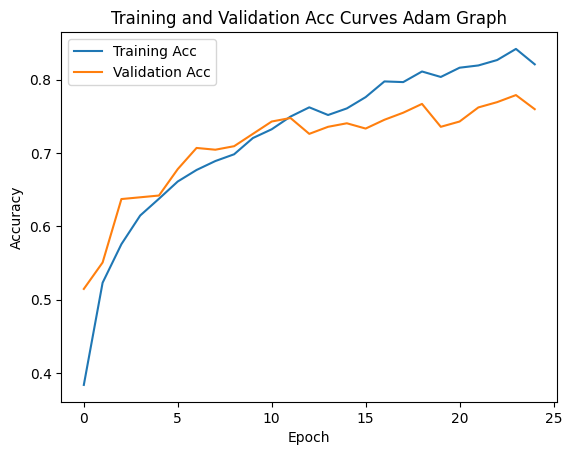

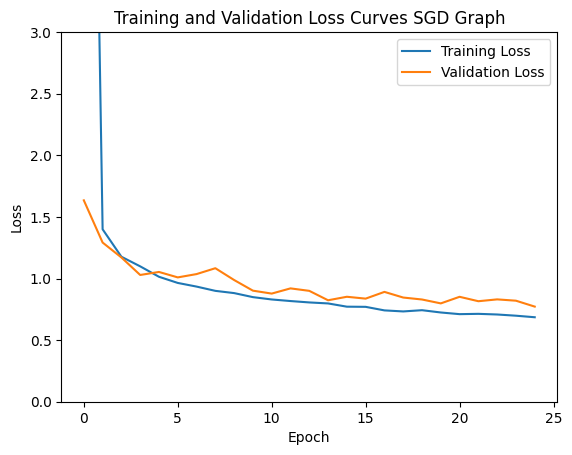

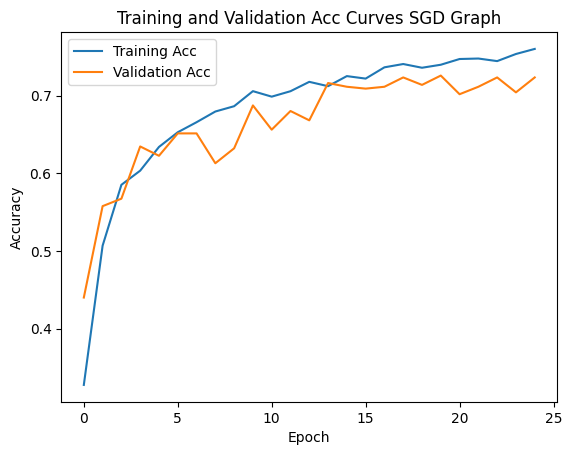

In [4]:
# Train and Test of Architecture Two using *un-weighted* Cross-Entropy Loss function

# Model Instance
model_one_a = ArchitectureTwo().to(device)
model_one_b = ArchitectureTwo().to(device)

# Epochs
num_epochs = 25

# Optimizer
adamOptimizer = optim.Adam(model_one_a.parameters(), lr=0.00001, weight_decay=0.01)
sdgOptimizer = optim.SGD(model_one_b.parameters(), lr=0.001, momentum=0.9)

# Loss Function
criterion = nn.CrossEntropyLoss()

(unweighted_train_losses_a, unweighted_val_losses_a, unweighted_train_accuracy_a, unweighted_val_accuracy_a, 
 unweighted_train_losses_b, unweighted_val_losses_b, unweighted_train_accuracy_b, unweighted_val_accuracy_b) = train(model_one_a, model_one_b, device, train_loader, val_loader, 
                                                                                                                        adamOptimizer, sdgOptimizer, None, None, num_epochs, criterion, 
                                                                                                                        'Custom All/Architecture Two/Unweighted Architecture Two Adam.pth', 
                                                                                                                        'Custom All/Architecture Two/Unweighted Architecture Two SGD.pth')

y_true, y_pred, y_score = test(model_one_a, device, criterion, test_loader, split='Test')
y_true, y_pred, y_score = test(model_one_b, device, criterion, test_loader, split='Test')
# Print metrics a
lossPlot(unweighted_train_losses_a, unweighted_val_losses_a, 'Adam Graph')
accuracyPlot(unweighted_train_accuracy_a, unweighted_val_accuracy_a,'Adam Graph')

# Print metrics b
lossPlot(unweighted_train_losses_b, unweighted_val_losses_b, 'SGD Graph')
accuracyPlot(unweighted_train_accuracy_b, unweighted_val_accuracy_b, 'SGD Graph')

{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]


100%|██████████| 203/203 [00:06<00:00, 32.12it/s]


Adam
Epoch 1/25, Training Loss: 1.8180, Validation Loss: 1.4800
Epoch 1/25, Training Acc: 34.64012041598249, Validation Accuracy: 47.355769230769226
SGD
Epoch 1/25, Training Loss: 8.8670, Validation Loss: 1.4113
Epoch 1/25, Training Acc: 37.73262178434592, Validation Accuracy: 48.55769230769231


100%|██████████| 203/203 [00:06<00:00, 32.10it/s]


Adam
Epoch 2/25, Training Loss: 1.3504, Validation Loss: 1.2130
Epoch 2/25, Training Acc: 51.52914614121511, Validation Accuracy: 60.33653846153846
SGD
Epoch 2/25, Training Loss: 1.2680, Validation Loss: 1.3229
Epoch 2/25, Training Acc: 54.662698412698404, Validation Accuracy: 51.92307692307693


...

Adam
Epoch 23/25, Training Loss: 0.4561, Validation Loss: 0.7706
Epoch 23/25, Training Acc: 83.79515599343185, Validation Accuracy: 72.59615384615384
SGD
Epoch 23/25, Training Loss: 0.4429, Validation Loss: 0.8533
Epoch 23/25, Training Acc: 84.00383141762453, Validation Accuracy: 69.23076923076923


100%|██████████| 203/203 [00:06<00:00, 32.03it/s]


Adam
Epoch 24/25, Training Loss: 0.4298, Validation Loss: 0.7620
Epoch 24/25, Training Acc: 84.73590585659551, Validation Accuracy: 72.59615384615384
SGD
Epoch 24/25, Training Loss: 0.4481, Validation Loss: 0.7968
Epoch 24/25, Training Acc: 83.81910235358511, Validation Accuracy: 72.59615384615384


100%|██████████| 203/203 [00:06<00:00, 31.84it/s]


Adam
Epoch 25/25, Training Loss: 0.4112, Validation Loss: 0.7564
Epoch 25/25, Training Acc: 85.8203338806787, Validation Accuracy: 75.48076923076923
SGD
Epoch 25/25, Training Loss: 0.3979, Validation Loss: 0.7880
Epoch 25/25, Training Acc: 85.78270388615216, Validation Accuracy: 73.07692307692307
Models saved successfully!


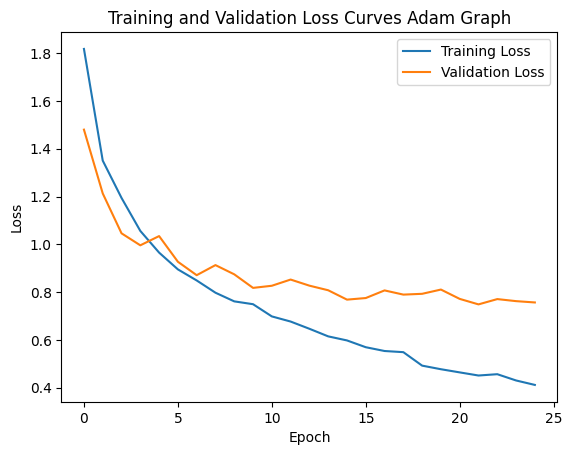

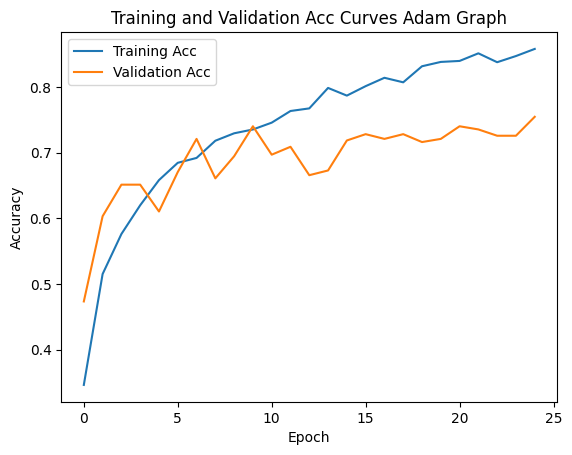

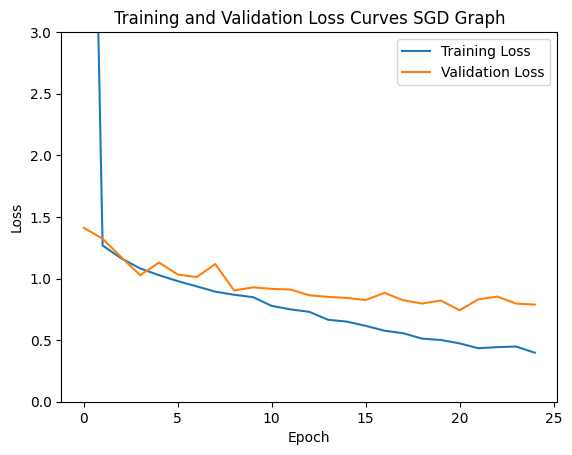

In [5]:
# Train and Test of ArchitectureOne using *weighted* Cross-Entropy Loss function
# Model Instance
model_one_weighted_a = ArchitectureTwo().to(device)
model_one_weighted_b = ArchitectureTwo().to(device)

# Epochs
num_epochs = 25

# Optimizer
weighted_adamOptimizer = optim.Adam(model_one_weighted_a.parameters(), lr=0.00001, weight_decay=0.01)
weighted_sgdOptimizer = optim.SGD(model_one_weighted_b.parameters(), lr=0.001, momentum=0.9)

# Loss Function
criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))

(weighted_train_losses_a, weighted_val_losses_a, weighted_train_accuracy_a, weighted_val_accuracy_a, 
 weighted_train_losses_b, weighted_val_losses_b, weighted_train_accuracy_b, weighted_val_accuracy_b) = train(model_one_weighted_a, model_one_weighted_b, device, train_loader, val_loader, 
                                                                                                                    weighted_adamOptimizer, weighted_sgdOptimizer, lr_scheduler_a= None, lr_scheduler_b=None, 
                                                                                                                    num_epochs=num_epochs, criterion=criterion, 
                                                                                                                    name_a= 'Custom All/Architecture Two/Weighted Architecture Two Adam.pth', 
                                                                                                                    name_b= 'Custom All/Architecture Two/Weighted Architecture Two SGD.pth')

# Print metrics a
lossPlot(weighted_train_losses_a, weighted_val_losses_a, 'Adam Graph')
accuracyPlot(weighted_train_accuracy_a, weighted_val_accuracy_a, 'Adam Graph')

# Print metrics b
lossPlot(weighted_train_losses_b, weighted_val_losses_b, 'SGD Graph')

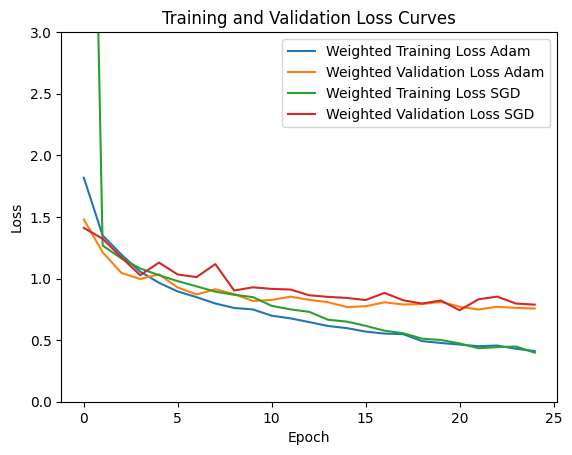

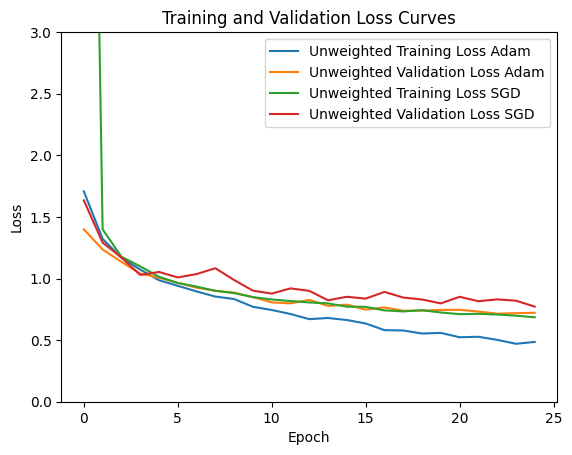

Adam unweighted Split Loss: 0.8370, Adam unweighted Split Accuracy: 71.32%
SGD unweighted Split Loss: 0.8587, SGD unweighted Split Accuracy: 70.34%
{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]
Adam weighted Split Loss: 0.8309, Adam weighted Split Accuracy: 71.57%
SGD weighted Split Loss: 0.9221, SGD weighted Split Accuracy: 71.57%
Fin


In [7]:
def lossPlotUnWeighted():
    plt.ylim(0,3)
    plt.plot(unweighted_train_losses_a, label='Unweighted Training Loss Adam')
    plt.plot(unweighted_val_losses_a, label='Unweighted Validation Loss Adam')

    plt.plot(unweighted_train_losses_b, label='Unweighted Training Loss SGD')
    plt.plot(unweighted_val_losses_b, label='Unweighted Validation Loss SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

def lossPlotWeighted():

    plt.ylim(0,3)
    plt.plot(weighted_train_losses_a, label='Weighted Training Loss Adam')
    plt.plot(weighted_val_losses_a, label='Weighted Validation Loss Adam')

    plt.plot(weighted_train_losses_b, label='Weighted Training Loss SGD')
    plt.plot(weighted_val_losses_b, label='Weighted Validation Loss SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

lossPlotWeighted()
lossPlotUnWeighted()

criterion = nn.CrossEntropyLoss()
test(model_one_a, device, criterion, test_loader, 'Adam unweighted Split')
test(model_one_b, device, criterion, test_loader, 'SGD unweighted Split')

criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
test(model_one_weighted_a, device, criterion, test_loader, 'Adam weighted Split')
test(model_one_weighted_b, device, criterion, test_loader, 'SGD weighted Split')

print('Fin')

